1. Converted timestamp to datetime format: To enable extraction of temporal information such as hour of day and day of week.
2. Created hour and day_of_week: Mental workload often occurs at specific times, so temporal context may improve prediction performance.
3. Calculated missing counts and percentages: To evaluate data quality and identify sensor reliability issues.
4. Applied linear interpolation to physiological signals: Smartwatch sensors occasionally miss measurements. Interpolation preserves temporal continuity without removing large amounts of data.
5. Replaced missing activity labels with "unknown": Preserves valuable observations while ensuring that all records contain a valid activity category.
6. Checked for duplicate rows: Duplicate observations can bias model training and evaluation.
7. Identified abnormal heart-rate and respiration-rate values: Sensor errors or unrealistic physiological measurements can negatively affect model performance.
8. Removed respiration values outside plausible physiological ranges: Improves data quality and reduces noise.
9. Examined cognitive vs non-cognitive labels: To identify potential class imbalance which may affect model training and evaluation.
10. Selected physiological and temporal variables (heart rate, respiration rate, stress, body battery, hour of day, and day of week): These variables were retained because they may capture both physiological responses and temporal patterns associated with mentally demanding tasks.
11. Standardized continuous variables using StandardScaler: Prevents features with larger numeric ranges from dominating the learning process. Particularly important for SVM and neural networks.
12. Saved full_df_preprocessed.csv: The resulting dataset contains 4,296 observations with no missing values in the selected physiological features and is ready for feature engineering and model development.

In [96]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


In [97]:
# load the dataset
df = pd.read_csv("../final_dfs/full_df.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape:
(4320, 7)

Columns:
['timestamp', 'stress', 'body_battery', 'respiration_rate', 'heart_rate', 'activity_type', 'is_cognitive']


,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,NaN,0
1,2026-06-03 00:01:00,12.0,32.0,13.58,NaN,NaN,0
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,generic,0
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,sedentary,0


In [98]:
# Convert Timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.dtypes)


timestamp           datetime64[us]
stress                     float64
body_battery               float64
respiration_rate           float64
heart_rate                 float64
activity_type                  str
is_cognitive                 int64
dtype: object


In [99]:
# Create Temporal Features
df["hour"] = df["timestamp"].dt.hour

df["day_of_week"] = df["timestamp"].dt.dayofweek

df[["timestamp", "hour", "day_of_week"]].head()

,timestamp,hour,day_of_week
0,2026-06-03 00:00:00,0,2
1,2026-06-03 00:01:00,0,2
2,2026-06-03 00:02:00,0,2
3,2026-06-03 00:03:00,0,2
4,2026-06-03 00:04:00,0,2


                  Missing Count  Missing Percentage
timestamp                     0                0.00
stress                      545               12.62
body_battery                213                4.93
respiration_rate            858               19.86
heart_rate                  805               18.63
activity_type               182                4.21
is_cognitive                  0                0.00
hour                          0                0.00
day_of_week                   0                0.00


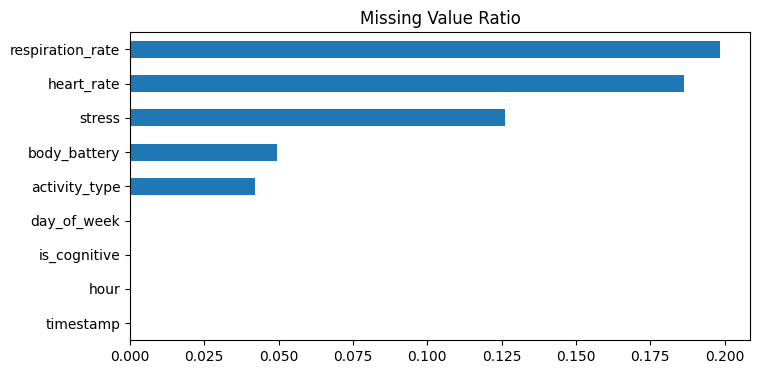

In [100]:
# Missing value analysis

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

print(missing_summary)

plt.figure(figsize=(8,4))

(df.isna().mean().sort_values()).plot(kind="barh")

plt.title("Missing Value Ratio")
plt.show()

In [101]:
sensor_cols = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate"
]

df[sensor_cols] = df[sensor_cols].interpolate(
    method="linear",
    limit_direction="both"
)

In [102]:
print(df.isna().sum())

timestamp             0
stress                0
body_battery          0
respiration_rate      0
heart_rate            0
activity_type       182
is_cognitive          0
hour                  0
day_of_week           0
dtype: int64


In [103]:
# Handle Missing Activity Labels

before_rows = len(df)

df["activity_type"] = df["activity_type"].fillna("unknown")

after_rows = len(df)

print("Rows Before:", before_rows)
print("Rows After :", after_rows)
print("Rows Removed:", before_rows - after_rows)

Rows Before: 4320
Rows After : 4320
Rows Removed: 0


In [104]:
# Duplicate Check
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# df = df.drop_duplicates()

Duplicate Rows: 0


In [105]:
# Outlier Detection
hr_outliers = df[
    (df["heart_rate"] < 30) |
    (df["heart_rate"] > 220)
]

print("Heart Rate Outliers:", len(hr_outliers))

resp_outliers = df[
    (df["respiration_rate"] < 5) |
    (df["respiration_rate"] > 40)
]

print("Respiration Outliers:", len(resp_outliers))

Heart Rate Outliers: 0
Respiration Outliers: 24


In [106]:
# Remove Outliers
df = df[
    (df["heart_rate"] >= 30) &
    (df["heart_rate"] <= 220)
]

df = df[
    (df["respiration_rate"] >= 5) &
    (df["respiration_rate"] <= 40)
]

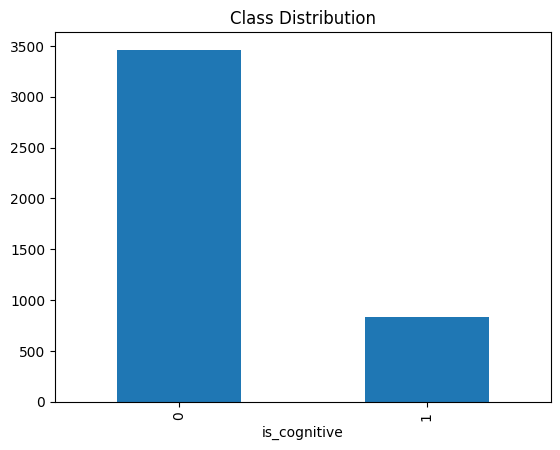

In [107]:
# Target Variable Check
df["is_cognitive"].value_counts()
df["is_cognitive"].value_counts(normalize=True)

df["is_cognitive"].value_counts().plot(kind="bar")

plt.title("Class Distribution")

plt.show()

In [108]:
# Feature Selection
features = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate",
    "hour",
    "day_of_week"
]

target = "is_cognitive"

In [109]:
# Feature Scaling
# day_of_week is categorical.
# Monday is not "halfway" between Sunday and Tuesday.

scaler = StandardScaler()

features_to_scale = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate",
    "hour"
]

df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

df[features_to_scale].describe()

,stress,body_battery,respiration_rate,heart_rate,hour
count,4.296000e+03,4.296000e+03,4.296000e+03,4.296000e+03,4.296000e+03
mean,5.292683e-17,1.323171e-17,-2.083994e-16,4.498781e-16,2.646342e-17
std,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00,1.000116e+00
min,-1.087467e+00,-1.604509e+00,-3.659386e+00,-1.532429e+00,-1.658453e+00
25%,-7.066069e-01,-8.753303e-01,-6.500757e-01,-7.882257e-01,-9.369921e-01
50%,-2.679123e-01,-1.005782e-01,4.607506e-02,-2.300733e-01,7.305294e-02
75%,4.359739e-01,8.564686e-01,6.596130e-01,5.761468e-01,7.945137e-01
max,3.186632e+00,1.859089e+00,3.425491e+00,5.227417e+00,1.660267e+00


In [110]:
# Final Dataset
print(df.shape)

df.head()

(4296, 9)


,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive,hour,day_of_week
0,2026-06-03 00:00:00,-0.495018,-1.103199,-0.319624,-0.416124,unknown,0,-1.658453,2
1,2026-06-03 00:01:00,-0.495018,-1.103199,-0.319624,-0.416124,unknown,0,-1.658453,2
2,2026-06-03 00:02:00,-0.156475,-1.103199,0.464647,-0.416124,unknown,0,-1.658453,2
3,2026-06-03 00:03:00,-0.114158,-1.103199,0.266376,0.204045,generic,0,-1.658453,2
4,2026-06-03 00:04:00,-0.071840,-1.103199,1.002181,-0.416124,sedentary,0,-1.658453,2


In [111]:
print(
    df["is_cognitive"]
    .value_counts(normalize=True)
)

is_cognitive
0    0.806099
1    0.193901
Name: proportion, dtype: float64


In [116]:
# Verify no missing values remain
print(df.isna().sum())

timestamp           0
stress              0
body_battery        0
respiration_rate    0
heart_rate          0
activity_type       0
is_cognitive        0
hour                0
day_of_week         0
dtype: int64


In [113]:
test=df.to_csv(
    "../final_dfs/full_df_preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


In [114]:
test = pd.read_csv("../final_dfs/full_df_preprocessed.csv")

print(test.shape)

test.head()

(4296, 9)


,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive,hour,day_of_week
0,2026-06-03 00:00:00,-0.495018,-1.103199,-0.319624,-0.416124,unknown,0,-1.658453,2
1,2026-06-03 00:01:00,-0.495018,-1.103199,-0.319624,-0.416124,unknown,0,-1.658453,2
2,2026-06-03 00:02:00,-0.156475,-1.103199,0.464647,-0.416124,unknown,0,-1.658453,2
3,2026-06-03 00:03:00,-0.114158,-1.103199,0.266376,0.204045,generic,0,-1.658453,2
4,2026-06-03 00:04:00,-0.071840,-1.103199,1.002181,-0.416124,sedentary,0,-1.658453,2
